In [4]:
import pandas as pd
import numpy as np

# Load all files with clear names
employee_data = pd.read_excel('employee_data_clean.xlsx')
engagement_data = pd.read_excel('employee_engagement_survey_data_clean.xlsx')
recruitment_data = pd.read_excel('recruitment_data_clean.xlsx')
training_data = pd.read_excel('training_and_development_data_clean.xlsx')

# Verify each file loaded correctly
print("=" * 50)
print("FILE 1: employee_data")
print(f"Shape: {employee_data.shape}")
print(f"Columns: {employee_data.columns.tolist()[:5]}...")  # First 5 columns

print("\n" + "=" * 50)
print("FILE 2: engagement_data")
print(f"Shape: {engagement_data.shape}")
print(f"Columns: {engagement_data.columns.tolist()}")

print("\n" + "=" * 50)
print("FILE 3: recruitment_data")
print(f"Shape: {recruitment_data.shape}")
print(f"Columns: {recruitment_data.columns.tolist()[:5]}...")

print("\n" + "=" * 50)
print("FILE 4: training_data")
print(f"Shape: {training_data.shape}")
print(f"Columns: {training_data.columns.tolist()[:5]}...")

FILE 1: employee_data
Shape: (3000, 27)
Columns: ['Employee ID', 'FirstName', 'LastName', 'StartDate', 'ExitDate']...

FILE 2: engagement_data
Shape: (3000, 5)
Columns: ['Employee ID', 'Survey Date', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score']

FILE 3: recruitment_data
Shape: (3000, 20)
Columns: ['Applicant ID', 'Application Date', 'First Name', 'Last Name', 'Gender']...

FILE 4: training_data
Shape: (3000, 9)
Columns: ['Employee ID', 'Training Date', 'Training Program Name', 'Training Type', 'Training Outcome']...


In [5]:
# Option 1: Merge employee_data with engagement_data (using Employee ID)
merged_employee_engagement = pd.merge(
    employee_data, 
    engagement_data, 
    on='Employee ID', 
    how='left'
)
print(f"Merged Employee + Engagement: {merged_employee_engagement.shape}")

# Option 2: Merge employee_data with training_data (using Employee ID)
merged_employee_training = pd.merge(
    employee_data, 
    training_data, 
    on='Employee ID', 
    how='left'
)
print(f"Merged Employee + Training: {merged_employee_training.shape}")

# Option 3: Merge all three (Employee + Engagement + Training)
master_data = pd.merge(
    pd.merge(employee_data, engagement_data, on='Employee ID', how='left'),
    training_data, 
    on='Employee ID', 
    how='left'
)
print(f"Master Data (all three): {master_data.shape}")

# Note: recruitment_data is kept separate since it contains applicants, not current employees

Merged Employee + Engagement: (3000, 31)
Merged Employee + Training: (3000, 35)
Master Data (all three): (3000, 39)


In [6]:
# Display first 5 rows of master_data
print("First 5 rows of master_data:")
print(master_data.head())

# Display all column names
print("\nAll columns in master_data (39 columns):")
print(master_data.columns.tolist())

First 5 rows of master_data:
   Employee ID FirstName LastName  StartDate ExitDate  \
0         3427     Uriah  Bridges 2019-09-20      NaT   
1         3428     Paula    Small 2023-02-11      NaT   
2         3429    Edward     Buck 2018-12-10      NaT   
3         3430   Michael  Riordan 2021-06-21      NaT   
4         3431   Jasmine    Onque 2019-06-29      NaT   

             Title_Cleaned       Supervisor                        ADEmail  \
0  Production Technician I     Peter Oneill    uriah.bridges@bilearner.com   
1  Production Technician I  Renee Mccormick      paula.small@bilearner.com   
2       Area Sales Manager   Crystal Walker      edward.buck@bilearner.com   
3       Area Sales Manager   Rebekah Wright  michael.riordan@bilearner.com   
4       Area Sales Manager        Jason Kim    jasmine.onque@bilearner.com   

  BusinessUnit EmployeeStatus_Corrected  ... Satisfaction Score  \
0         CCDR                   Active  ...                  2   
1           EW           

In [7]:
# Check for missing values in master_data
print("Missing values in each column:")
print(master_data.isnull().sum())

# Check data types
print("\nData types:")
print(master_data.dtypes)

# Basic statistics for numeric columns
print("\nBasic statistics for numeric columns:")
print(master_data.describe())

Missing values in each column:
Employee ID                    0
FirstName                      0
LastName                       0
StartDate                      0
ExitDate                    1467
Title_Cleaned                  0
Supervisor                     0
ADEmail                        0
BusinessUnit                   0
EmployeeStatus_Corrected       0
EmployeeType                   0
PayZone                        0
TerminationType                0
TerminationDescription      1467
Department_Corrected           0
Division                       0
DOB                            0
Age                            0
Age_Group                      0
State                          0
JobFunction_Clean              0
GenderCode                     0
LocationCode                   0
RaceDesc                       0
MaritalDesc                    0
Performance Score              0
Current Employee Rating        0
Survey Date                    0
Engagement Score               0
Satisfaction

In [8]:
# Create a clear离职 status column
import numpy as np

# Add a clear status column
master_data['Status'] = np.where(master_data['ExitDate'].isna(), 'Active', 'Terminated')

# Compare active vs terminated employees
print("=" * 60)
print("EMPLOYEE STATUS DISTRIBUTION:")
print(master_data['Status'].value_counts())
print(f"\nTurnover Rate: {1533/3000*100:.1f}%")

# Compare Age between Active and Terminated
print("\n" + "=" * 60)
print("AGE COMPARISON (Active vs Terminated):")
print(master_data.groupby('Status')['Age'].describe())

# Compare Performance Rating
print("\n" + "=" * 60)
print("PERFORMANCE RATING COMPARISON:")
print(master_data.groupby('Status')['Current Employee Rating'].describe())

# Compare by Department
print("\n" + "=" * 60)
print("DEPARTMENT COMPARISON:")
dept_status = pd.crosstab(master_data['Department_Corrected'], master_data['Status'], normalize='index') * 100
print(dept_status.round(1))

EMPLOYEE STATUS DISTRIBUTION:
Status
Terminated    1533
Active        1467
Name: count, dtype: int64

Turnover Rate: 51.1%

AGE COMPARISON (Active vs Terminated):
             count       mean        std   min   25%   50%   75%   max
Status                                                                
Active      1467.0  51.752556  17.678368  22.0  36.0  52.0  67.0  82.0
Terminated  1533.0  51.859100  17.711526  22.0  36.0  51.0  67.0  82.0

PERFORMANCE RATING COMPARISON:
             count      mean       std  min  25%  50%  75%  max
Status                                                         
Active      1467.0  2.961145  1.021189  1.0  2.0  3.0  3.0  5.0
Terminated  1533.0  2.976517  1.009470  1.0  2.0  3.0  3.0  5.0

DEPARTMENT COMPARISON:
Status                Active  Terminated
Department_Corrected                    
Admin Offices           47.0        53.0
Executive Office        47.1        52.9
IT/IS                   46.9        53.1
Production              49.7        

In [9]:
# Compare Engagement, Satisfaction, and Work-Life Balance between Active and Terminated
print("=" * 60)
print("ENGAGEMENT SCORE COMPARISON:")
print(master_data.groupby('Status')['Engagement Score'].describe())

print("\n" + "=" * 60)
print("SATISFACTION SCORE COMPARISON:")
print(master_data.groupby('Status')['Satisfaction Score'].describe())

print("\n" + "=" * 60)
print("WORK-LIFE BALANCE SCORE COMPARISON:")
print(master_data.groupby('Status')['Work-Life Balance Score'].describe())

# Visual comparison with averages
print("\n" + "=" * 60)
print("AVERAGE SCORES COMPARISON:")
scores_df = master_data.groupby('Status')[['Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score']].mean()
print(scores_df.round(2))

ENGAGEMENT SCORE COMPARISON:
             count      mean       std  min  25%  50%  75%  max
Status                                                         
Active      1467.0  2.940695  1.430481  1.0  2.0  3.0  4.0  5.0
Terminated  1533.0  2.938682  1.436706  1.0  2.0  3.0  4.0  5.0

SATISFACTION SCORE COMPARISON:
             count      mean       std  min  25%  50%  75%  max
Status                                                         
Active      1467.0  3.034083  1.410905  1.0  2.0  3.0  4.0  5.0
Terminated  1533.0  3.010437  1.407234  1.0  2.0  3.0  4.0  5.0

WORK-LIFE BALANCE SCORE COMPARISON:
             count      mean       std  min  25%  50%  75%  max
Status                                                         
Active      1467.0  3.027267  1.394520  1.0  2.0  3.0  4.0  5.0
Terminated  1533.0  2.952381  1.422847  1.0  2.0  3.0  4.0  5.0

AVERAGE SCORES COMPARISON:
            Engagement Score  Satisfaction Score  Work-Life Balance Score
Status                          

In [10]:
# Compare Training factors between Active and Terminated
print("=" * 60)
print("TRAINING OUTCOME COMPARISON:")
training_status = pd.crosstab(master_data['Training Outcome'], master_data['Status'], normalize='index') * 100
print(training_status.round(1))

print("\n" + "=" * 60)
print("TRAINING TYPE COMPARISON:")
training_type = pd.crosstab(master_data['Training Type'], master_data['Status'], normalize='index') * 100
print(training_type.round(1))

print("\n" + "=" * 60)
print("TRAINING DURATION COMPARISON:")
print(master_data.groupby('Status')['Training Duration(Days)'].describe())

print("\n" + "=" * 60)
print("TRAINING COST COMPARISON:")
print(master_data.groupby('Status')['Training Cost'].describe())

TRAINING OUTCOME COMPARISON:
Status            Active  Terminated
Training Outcome                    
Completed           51.4        48.6
Failed              45.7        54.3
Incomplete          47.1        52.9

TRAINING TYPE COMPARISON:
Status         Active  Terminated
Training Type                    
External         49.0        51.0
Internal         48.8        51.2

TRAINING DURATION COMPARISON:
             count      mean       std  min  25%  50%  75%  max
Status                                                         
Active      1467.0  2.973415  1.429556  1.0  2.0  3.0  4.0  5.0
Terminated  1533.0  2.977821  1.407098  1.0  2.0  3.0  4.0  5.0

TRAINING COST COMPARISON:
             count        mean         std     min      25%     50%      75%  \
Status                                                                         
Active      1467.0  557.911691  266.711506  100.04  322.785  569.50  791.885   
Terminated  1533.0  559.314834  259.915581  100.17  331.520  573.33  

In [11]:
# Analyze relationship between Training Outcome, Department, and Turnover
print("=" * 60)
print("TRAINING OUTCOME BY DEPARTMENT (Terminated %):")

# Create a pivot table showing termination rate by Department and Training Outcome
dept_training_outcome = pd.crosstab(
    [master_data['Department_Corrected'], master_data['Training Outcome']], 
    master_data['Status'], 
    normalize='index'
) * 100

# Show only Terminated percentage
dept_training_outcome_term = dept_training_outcome['Terminated'].unstack()
print(dept_training_outcome_term.round(1))

print("\n" + "=" * 60)
print("PRODUCTION DEPARTMENT - Detailed view:")
production_data = master_data[master_data['Department_Corrected'] == 'Production']
prod_outcome = pd.crosstab(production_data['Training Outcome'], production_data['Status'], normalize='index') * 100
print(prod_outcome.round(1))

print("\n" + "=" * 60)
print("SOFTWARE ENGINEERING DEPARTMENT - Detailed view:")
se_data = master_data[master_data['Department_Corrected'] == 'Software Engineering']
se_outcome = pd.crosstab(se_data['Training Outcome'], se_data['Status'], normalize='index') * 100
print(se_outcome.round(1))

TRAINING OUTCOME BY DEPARTMENT (Terminated %):
Training Outcome      Completed  Failed  Incomplete
Department_Corrected                               
Admin Offices              44.6    62.5        62.3
Executive Office           51.9    44.0        64.0
IT/IS                      48.7    60.2        55.6
Production                 49.2    52.4        50.4
Sales                      42.3    50.0        62.5
Software Engineering       47.6    55.6        71.4

PRODUCTION DEPARTMENT - Detailed view:
Status            Active  Terminated
Training Outcome                    
Completed           50.8        49.2
Failed              47.6        52.4
Incomplete          49.6        50.4

SOFTWARE ENGINEERING DEPARTMENT - Detailed view:
Status            Active  Terminated
Training Outcome                    
Completed           52.4        47.6
Failed              44.4        55.6
Incomplete          28.6        71.4


In [12]:
# Create a deep analysis combining multiple factors
print("=" * 60)
print("DEEP ANALYSIS: Department + Training Outcome + Satisfaction")

# Group by Department, Training Outcome, and Status to see patterns
deep_analysis = master_data.groupby(
    ['Department_Corrected', 'Training Outcome', 'Status']
).size().unstack(fill_value=0)

# Calculate termination rate for each group
deep_analysis['Termination_Rate'] = (
    deep_analysis['Terminated'] / (deep_analysis['Active'] + deep_analysis['Terminated']) * 100
)

print(deep_analysis[['Active', 'Terminated', 'Termination_Rate']].round(1))

print("\n" + "=" * 60)
print("CORRELATION: Satisfaction Score vs Turnover by Department")

# Compare average satisfaction for active vs terminated by department
satisfaction_by_dept = master_data.groupby(
    ['Department_Corrected', 'Status']
)['Satisfaction Score'].mean().unstack()

print(satisfaction_by_dept.round(2))

DEEP ANALYSIS: Department + Training Outcome + Satisfaction
Status                                 Active  Terminated  Termination_Rate
Department_Corrected Training Outcome                                      
Admin Offices        Completed             72          58              44.6
                     Failed                24          40              62.5
                     Incomplete            20          33              62.3
Executive Office     Completed             26          28              51.9
                     Failed                14          11              44.0
                     Incomplete             9          16              64.0
IT/IS                Completed            135         128              48.7
                     Failed                49          74              60.2
                     Incomplete            52          65              55.6
Production           Completed            516         499              49.2
                     Failed 

In [13]:
# Analyze Termination Type by Department
print("=" * 60)
print("TERMINATION TYPE BY DEPARTMENT:")

# Create cross tabulation
termination_by_dept = pd.crosstab(
    master_data[master_data['Status'] == 'Terminated']['Department_Corrected'],
    master_data[master_data['Status'] == 'Terminated']['TerminationType'],
    normalize='index'
) * 100

print(termination_by_dept.round(1))

print("\n" + "=" * 60)
print("WHY DO DIFFERENT DEPARTMENTS LOSE EMPLOYEES?")

# Focus on Sales department's termination reasons
sales_term = master_data[(master_data['Department_Corrected'] == 'Sales') & 
                          (master_data['Status'] == 'Terminated')]
print("\nSales Department - Termination Reasons:")
print(sales_term['TerminationType'].value_counts())

print("\nSoftware Engineering - Termination Reasons:")
se_term = master_data[(master_data['Department_Corrected'] == 'Software Engineering') & 
                       (master_data['Status'] == 'Terminated')]
print(se_term['TerminationType'].value_counts())

print("\nProduction - Termination Reasons:")
prod_term = master_data[(master_data['Department_Corrected'] == 'Production') & 
                         (master_data['Status'] == 'Terminated')]
print(prod_term['TerminationType'].value_counts())

TERMINATION TYPE BY DEPARTMENT:
TerminationType       Involuntary  Retirement  Voluntary
Department_Corrected                                    
Admin Offices                26.0        20.6       53.4
Executive Office             27.3        18.2       54.5
IT/IS                        27.7        23.2       49.1
Production                   25.0        25.5       49.4
Sales                        10.0        36.7       53.3
Software Engineering         20.0        20.0       60.0

WHY DO DIFFERENT DEPARTMENTS LOSE EMPLOYEES?

Sales Department - Termination Reasons:
TerminationType
Voluntary      16
Retirement     11
Involuntary     3
Name: count, dtype: int64

Software Engineering - Termination Reasons:
TerminationType
Voluntary      12
Retirement      4
Involuntary     4
Name: count, dtype: int64

Production - Termination Reasons:
TerminationType
Voluntary      509
Retirement     263
Involuntary    258
Name: count, dtype: int64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Arabic-friendly style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Check Gender distribution and turnover by Gender
print("=" * 60)
print("GENDER DISTRIBUTION IN MASTER DATA:")
print(master_data['GenderCode'].value_counts())

print("\n" + "=" * 60)
print("TURNOVER RATE BY GENDER:")
gender_turnover = pd.crosstab(master_data['GenderCode'], master_data['Status'], normalize='index') * 100
print(gender_turnover.round(1))

print("\n" + "=" * 60)
print("SATISFACTION SCORE BY GENDER AND STATUS:")
gender_satisfaction = master_data.groupby(['GenderCode', 'Status'])['Satisfaction Score'].mean().unstack()
print(gender_satisfaction.round(2))

print("\n" + "=" * 60)
print("TRAINING OUTCOME BY GENDER:")
gender_training = pd.crosstab(master_data['GenderCode'], master_data['Training Outcome'], normalize='index') * 100
print(gender_training.round(1))

GENDER DISTRIBUTION IN MASTER DATA:
GenderCode
Female    1682
Male      1318
Name: count, dtype: int64

TURNOVER RATE BY GENDER:
Status      Active  Terminated
GenderCode                    
Female        48.6        51.4
Male          49.3        50.7

SATISFACTION SCORE BY GENDER AND STATUS:
Status      Active  Terminated
GenderCode                    
Female        3.01        3.00
Male          3.07        3.02

TRAINING OUTCOME BY GENDER:
Training Outcome  Completed  Failed  Incomplete
GenderCode                                     
Female                 48.9    24.4        26.8
Male                   52.1    23.2        24.7


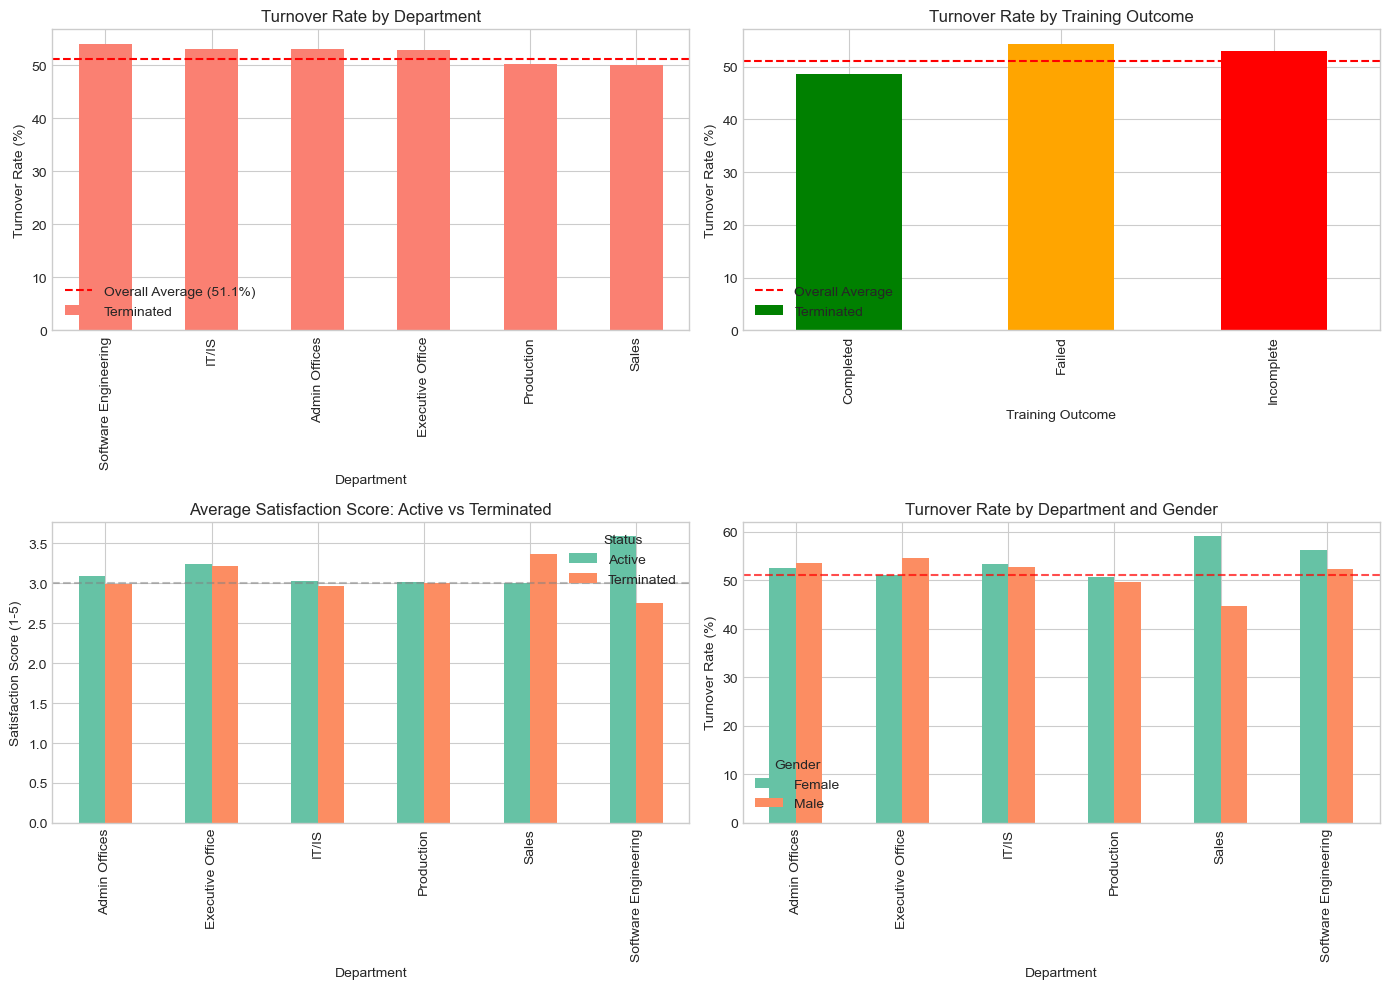

In [15]:
# Create visualizations

# Figure 1: Turnover rate by Department and Gender
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Turnover by Department
dept_turnover = pd.crosstab(master_data['Department_Corrected'], master_data['Status'], normalize='index') * 100
dept_turnover['Terminated'].sort_values(ascending=False).plot(kind='bar', ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Turnover Rate by Department', fontsize=12)
axes[0, 0].set_ylabel('Turnover Rate (%)')
axes[0, 0].set_xlabel('Department')
axes[0, 0].axhline(y=51.1, color='red', linestyle='--', label='Overall Average (51.1%)')
axes[0, 0].legend()

# Plot 2: Turnover by Training Outcome
training_turnover = pd.crosstab(master_data['Training Outcome'], master_data['Status'], normalize='index') * 100
training_turnover['Terminated'].plot(kind='bar', ax=axes[0, 1], color=['green', 'orange', 'red'])
axes[0, 1].set_title('Turnover Rate by Training Outcome', fontsize=12)
axes[0, 1].set_ylabel('Turnover Rate (%)')
axes[0, 1].axhline(y=51.1, color='red', linestyle='--', label='Overall Average')
axes[0, 1].legend()

# Plot 3: Satisfaction comparison by Department (Active vs Terminated)
sat_comparison = master_data.groupby(['Department_Corrected', 'Status'])['Satisfaction Score'].mean().unstack()
sat_comparison.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Average Satisfaction Score: Active vs Terminated', fontsize=12)
axes[1, 0].set_ylabel('Satisfaction Score (1-5)')
axes[1, 0].set_xlabel('Department')
axes[1, 0].legend(title='Status')
axes[1, 0].axhline(y=3.0, color='gray', linestyle='--', alpha=0.5)

# Plot 4: Turnover by Gender and Department
gender_dept_turnover = pd.crosstab([master_data['Department_Corrected'], master_data['GenderCode']], master_data['Status'], normalize='index') * 100
gender_dept_turnover_term = gender_dept_turnover['Terminated'].unstack()
gender_dept_turnover_term.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Turnover Rate by Department and Gender', fontsize=12)
axes[1, 1].set_ylabel('Turnover Rate (%)')
axes[1, 1].set_xlabel('Department')
axes[1, 1].legend(title='Gender')
axes[1, 1].axhline(y=51.1, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

CORRELATION MATRIX (Numerical Variables)
                          Age  Current Employee Rating  Engagement Score  \
Age                      1.00                    -0.02             -0.03   
Current Employee Rating -0.02                     1.00              0.02   
Engagement Score        -0.03                     0.02              1.00   
Satisfaction Score       0.00                    -0.03             -0.01   
Work-Life Balance Score -0.01                     0.03              0.02   
Training Duration(Days)  0.01                     0.00              0.01   
Training Cost           -0.00                     0.01              0.02   

                         Satisfaction Score  Work-Life Balance Score  \
Age                                    0.00                    -0.01   
Current Employee Rating               -0.03                     0.03   
Engagement Score                      -0.01                     0.02   
Satisfaction Score                     1.00                   

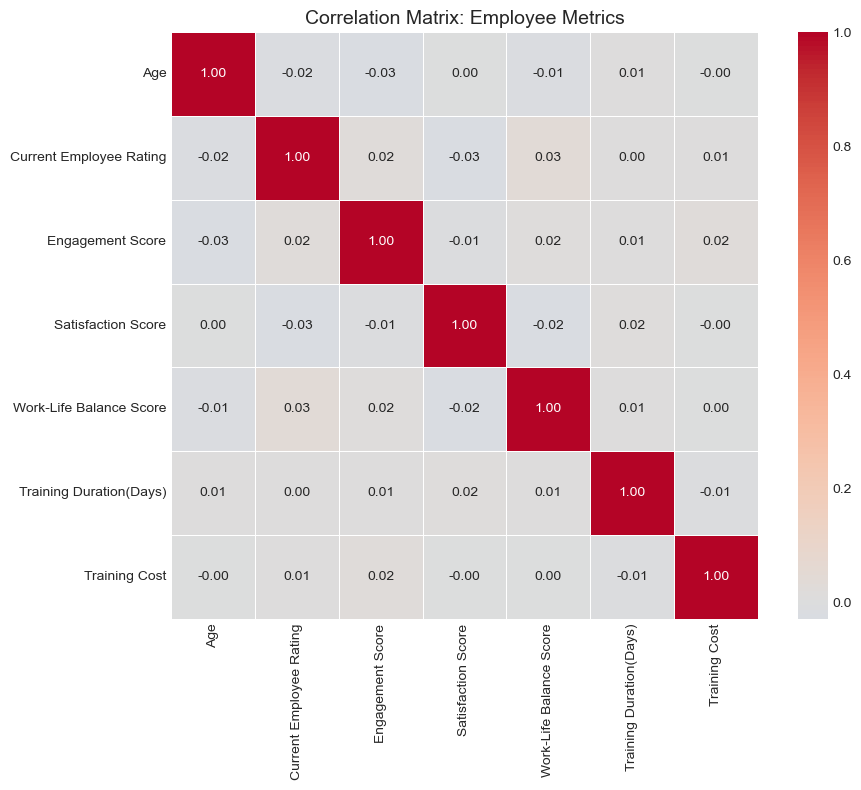

In [16]:
# Correlation analysis
print("=" * 60)
print("CORRELATION MATRIX (Numerical Variables)")

# Select numerical columns for correlation
numerical_cols = ['Age', 'Current Employee Rating', 'Engagement Score', 
                  'Satisfaction Score', 'Work-Life Balance Score', 
                  'Training Duration(Days)', 'Training Cost']

correlation_matrix = master_data[numerical_cols].corr()

# Display correlation matrix
print(correlation_matrix.round(2))

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Employee Metrics', fontsize=14)
plt.tight_layout()
plt.show()

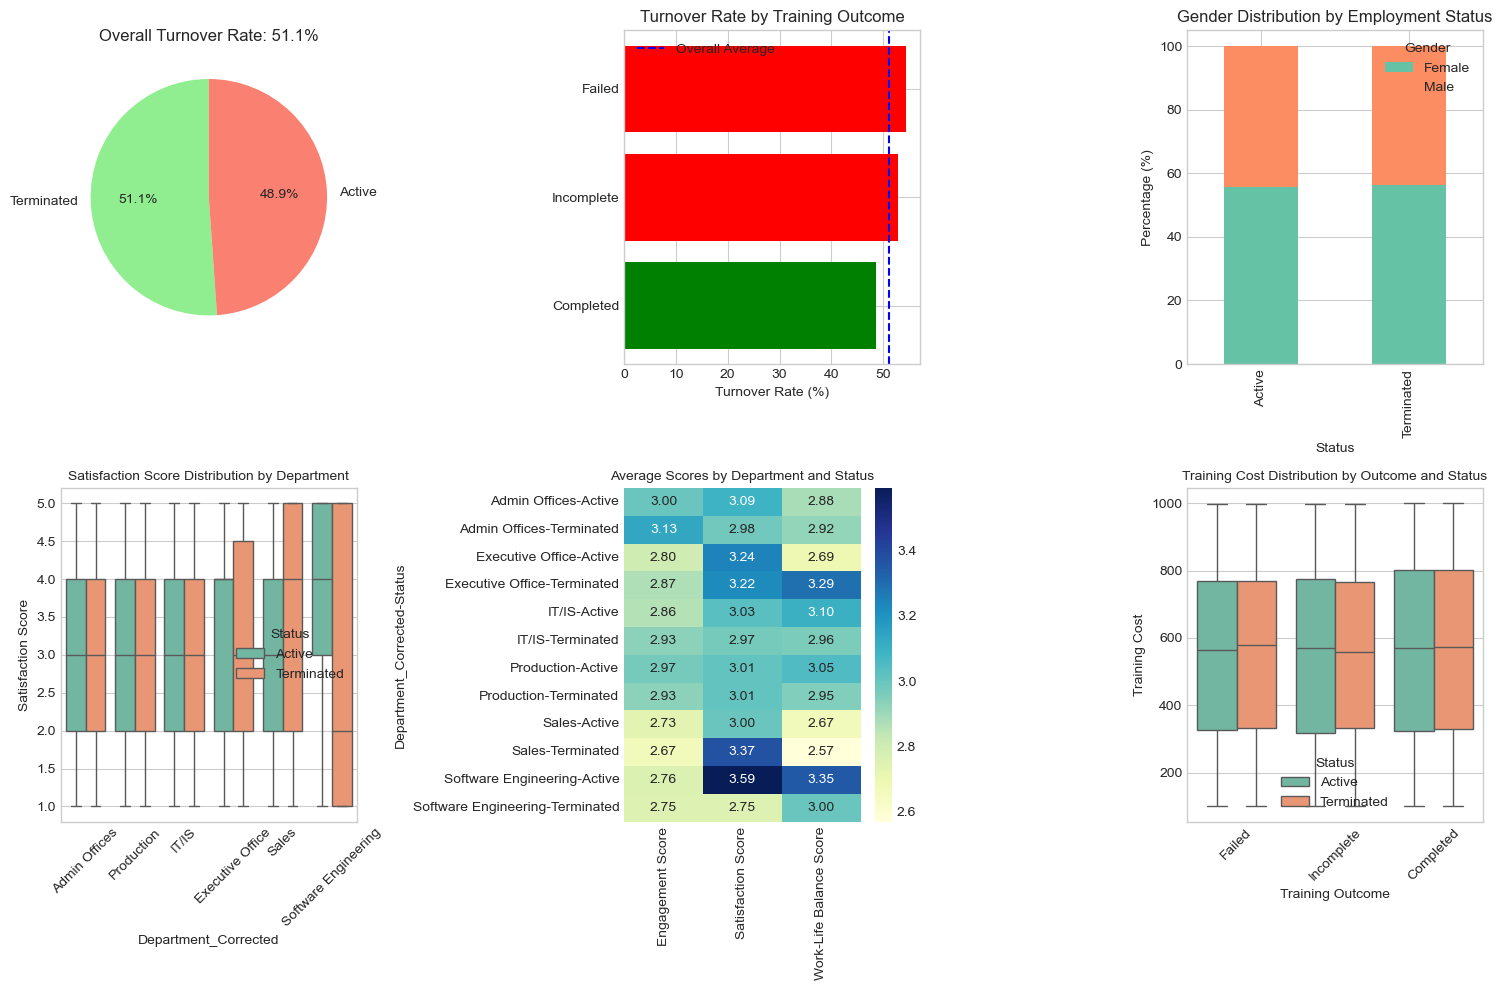

In [17]:
# Create a comprehensive summary visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Overall Turnover Pie Chart
turnover_counts = master_data['Status'].value_counts()
axes[0, 0].pie(turnover_counts, labels=turnover_counts.index, autopct='%1.1f%%', 
               colors=['lightgreen', 'salmon'], startangle=90)
axes[0, 0].set_title('Overall Turnover Rate: 51.1%', fontsize=12)

# 2. Turnover by Training Outcome (with counts)
training_counts = pd.crosstab(master_data['Training Outcome'], master_data['Status'])
training_turnover_rate = (training_counts['Terminated'] / training_counts.sum(axis=1) * 100).sort_values()
colors = ['red' if x > 51 else 'green' for x in training_turnover_rate]
axes[0, 1].barh(training_turnover_rate.index, training_turnover_rate.values, color=colors)
axes[0, 1].set_xlabel('Turnover Rate (%)')
axes[0, 1].set_title('Turnover Rate by Training Outcome', fontsize=12)
axes[0, 1].axvline(x=51.1, color='blue', linestyle='--', label='Overall Average')
axes[0, 1].legend()

# 3. Gender Distribution by Status
gender_status = pd.crosstab(master_data['GenderCode'], master_data['Status'], normalize='columns') * 100
gender_status.T.plot(kind='bar', ax=axes[0, 2], stacked=True)
axes[0, 2].set_title('Gender Distribution by Employment Status', fontsize=12)
axes[0, 2].set_ylabel('Percentage (%)')
axes[0, 2].legend(title='Gender')

# 4. Boxplot - Satisfaction Score by Department and Status
sns.boxplot(data=master_data, x='Department_Corrected', y='Satisfaction Score', 
            hue='Status', ax=axes[1, 0])
axes[1, 0].set_title('Satisfaction Score Distribution by Department', fontsize=10)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Status')

# 5. Heatmap - Average Scores by Department and Status
scores_heatmap = master_data.groupby(['Department_Corrected', 'Status'])[
    ['Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score']
].mean().round(2)
sns.heatmap(scores_heatmap, annot=True, cmap='YlGnBu', ax=axes[1, 1], fmt='.2f')
axes[1, 1].set_title('Average Scores by Department and Status', fontsize=10)

# 6. Training Cost vs Outcome by Status
sns.boxplot(data=master_data, x='Training Outcome', y='Training Cost', hue='Status', ax=axes[1, 2])
axes[1, 2].set_title('Training Cost Distribution by Outcome and Status', fontsize=10)
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [18]:
# First, let's explore the recruitment_data
print("=" * 60)
print("RECRUITMENT DATA - First 5 rows:")
print(recruitment_data.head())

print("\n" + "=" * 60)
print("RECRUITMENT DATA - Info:")
print(recruitment_data.info())

print("\n" + "=" * 60)
print("RECRUITMENT DATA - Column names:")
print(recruitment_data.columns.tolist())

print("\n" + "=" * 60)
print("RECRUITMENT DATA - Shape:")
print(f"Rows: {recruitment_data.shape[0]}, Columns: {recruitment_data.shape[1]}")

RECRUITMENT DATA - First 5 rows:
   Applicant ID Application Date   First Name Last Name  Gender  \
0          1001       2023-06-03        Scott  Sheppard    Male   
1          1002       2023-05-15      Stanley     Lewis    Male   
2          1003       2023-08-04       Javier        Li  Female   
3          1004       2023-07-28  Christopher  Johnston   Other   
4          1005       2023-06-05      Melissa     Hicks   Other   

         Date of Birth  Age     Age_Group          Phone Number  \
0           1992-08-31   31         25-34    421-429-7655x39421   
1  1965-04-29 00:00:00   58  55 and above  +1-451-574-5308x1681   
2           1973-03-10   50         45-54         (858)901-5499   
3           2001-04-04   22  Less than 25    (853)681-1839x2010   
4           1978-06-17   45         45-54    364-575-8478x67812   

                        Email                        Address  \
0      perezjanet@example.org                597 Smith Point   
1       grossmark@example.com    

APPLICATION STATUS DISTRIBUTION:
Status
Applied         611
Offered         610
In Review       595
Rejected        594
Interviewing    590
Name: count, dtype: int64

Percentages:
Status
Applied         20.4
Offered         20.3
In Review       19.8
Rejected        19.8
Interviewing    19.7
Name: count, dtype: float64


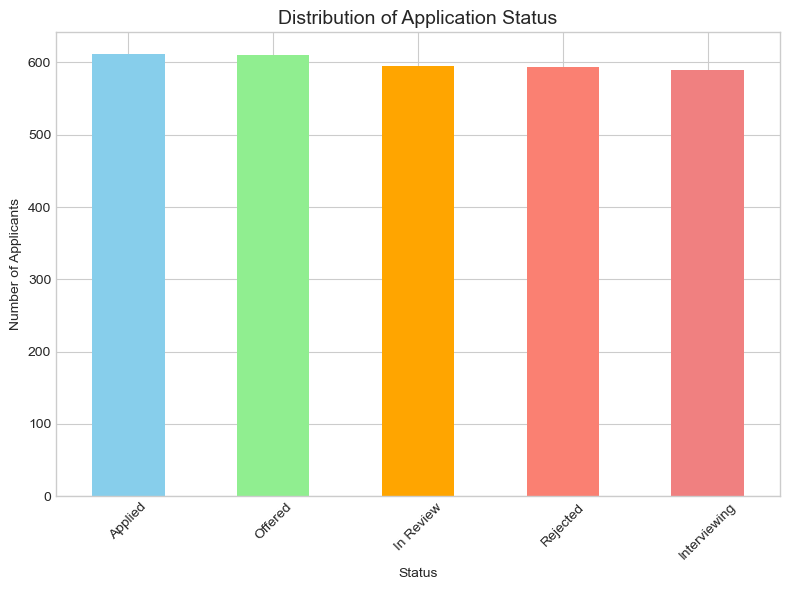

In [19]:
print("=" * 60)
print("APPLICATION STATUS DISTRIBUTION:")
status_dist = recruitment_data['Status'].value_counts()
print(status_dist)
print(f"\nPercentages:")
print((status_dist / len(recruitment_data) * 100).round(1))

# Visualize
plt.figure(figsize=(8, 6))
status_dist.plot(kind='bar', color=['skyblue', 'lightgreen', 'orange', 'salmon', 'lightcoral'])
plt.title('Distribution of Application Status', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
print("=" * 60)
print("EDUCATION LEVEL DISTRIBUTION:")
edu_dist = recruitment_data['Education Level'].value_counts()
print(edu_dist)
print(f"\nPercentages:")
print((edu_dist / len(recruitment_data) * 100).round(1))

# Education vs Status
print("\n" + "=" * 60)
print("EDUCATION LEVEL vs APPLICATION STATUS:")
edu_status = pd.crosstab(recruitment_data['Education Level'], recruitment_data['Status'], normalize='index') * 100
print(edu_status.round(1))

EDUCATION LEVEL DISTRIBUTION:
Education Level
Bachelor's Degree    785
PhD                  741
High School          738
Master's Degree      736
Name: count, dtype: int64

Percentages:
Education Level
Bachelor's Degree    26.2
PhD                  24.7
High School          24.6
Master's Degree      24.5
Name: count, dtype: float64

EDUCATION LEVEL vs APPLICATION STATUS:
Status             Applied  In Review  Interviewing  Offered  Rejected
Education Level                                                       
Bachelor's Degree     20.9       16.9          21.9     20.0      20.3
High School           19.9       21.4          19.0     19.1      20.6
Master's Degree       20.2       20.2          18.6     22.3      18.6
PhD                   20.4       20.9          19.0     20.0      19.7


APPLICATIONS BY MONTH:
May: 808 applicants
June: 983 applicants
July: 1047 applicants
August: 162 applicants


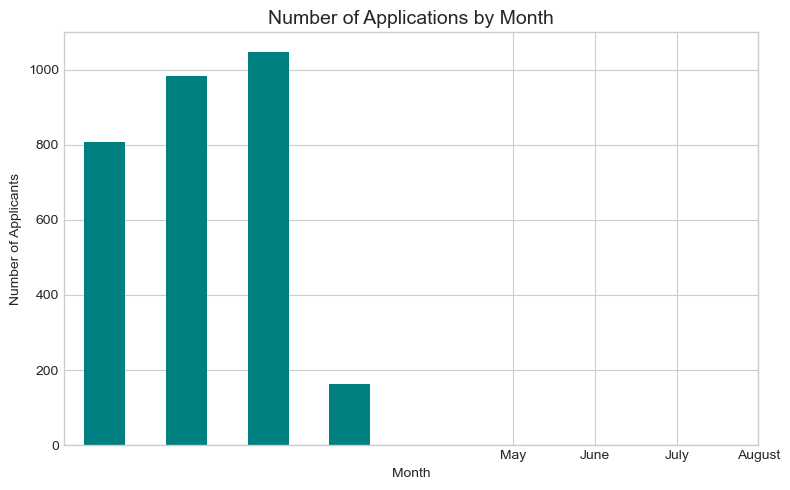

In [23]:
# Extract month from Application Date
recruitment_data['Application Month'] = pd.to_datetime(recruitment_data['Application Date']).dt.month

print("=" * 60)
print("APPLICATIONS BY MONTH:")
monthly_apps = recruitment_data['Application Month'].value_counts().sort_index()
month_names = {5: 'May', 6: 'June', 7: 'July', 8: 'August'}
for month in monthly_apps.index:
    print(f"{month_names.get(month, month)}: {monthly_apps[month]} applicants")

# Visualize
plt.figure(figsize=(8, 5))
monthly_apps.plot(kind='bar', color='teal')
plt.title('Number of Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applicants')
plt.xticks(ticks=range(5, 9), labels=['May', 'June', 'July', 'August'], rotation=0)
plt.tight_layout()
plt.show()

In [22]:
print("=" * 60)
print("GENDER DISTRIBUTION:")
gender_dist = recruitment_data['Gender'].value_counts()
print(gender_dist)
print(f"\nPercentages:")
print((gender_dist / len(recruitment_data) * 100).round(1))

# Gender vs Status
print("\n" + "=" * 60)
print("GENDER vs APPLICATION STATUS:")
gender_status = pd.crosstab(recruitment_data['Gender'], recruitment_data['Status'], normalize='index') * 100
print(gender_status.round(1))

print("\n" + "=" * 60)
print("AGE ANALYSIS:")
print(f"Minimum Age: {recruitment_data['Age'].min()}")
print(f"Maximum Age: {recruitment_data['Age'].max()}")
print(f"Average Age: {recruitment_data['Age'].mean():.1f}")

GENDER DISTRIBUTION:
Gender
Male      1030
Other     1003
Female     967
Name: count, dtype: int64

Percentages:
Gender
Male      34.3
Other     33.4
Female    32.2
Name: count, dtype: float64

GENDER vs APPLICATION STATUS:
Status  Applied  In Review  Interviewing  Offered  Rejected
Gender                                                     
Female     20.3       20.3          19.5     20.8      19.1
Male       19.8       19.4          19.1     21.1      20.6
Other      21.0       19.8          20.3     19.1      19.6

AGE ANALYSIS:
Minimum Age: 18
Maximum Age: 61
Average Age: 39.9


In [24]:
print("=" * 60)
print("RECRUITMENT DATA - KEY FINDINGS SUMMARY")
print("=" * 60)

print("\n1. Application Status (Balanced distribution):")
for status, count in status_dist.items():
    print(f"   - {status}: {count} ({count/30:.1f}%)")

print(f"\n2. Education Level (Balanced):")
for edu, count in edu_dist.items():
    print(f"   - {edu}: {count}")

print(f"\n4. Gender Distribution:")
for gender, count in gender_dist.items():
    print(f"   - {gender}: {count} ({count/30:.1f}%)")

print(f"\n5. Peak Application Month: June ({monthly_apps[6]} applications)")

RECRUITMENT DATA - KEY FINDINGS SUMMARY

1. Application Status (Balanced distribution):
   - Applied: 611 (20.4%)
   - Offered: 610 (20.3%)
   - In Review: 595 (19.8%)
   - Rejected: 594 (19.8%)
   - Interviewing: 590 (19.7%)

2. Education Level (Balanced):
   - Bachelor's Degree: 785
   - PhD: 741
   - High School: 738
   - Master's Degree: 736

4. Gender Distribution:
   - Male: 1030 (34.3%)
   - Other: 1003 (33.4%)
   - Female: 967 (32.2%)

5. Peak Application Month: June (983 applications)


In [25]:
# Merge recruitment offers with employee data
offered_applicants = recruitment_data[recruitment_data['Status'] == 'Offered']

# Check if they appear in employee_data by name or email
# (Note: No direct common column, we would need fuzzy matching)
print("Offered applicants count:", len(offered_applicants))
print("Employee data count:", len(employee_data))

Offered applicants count: 610
Employee data count: 3000


In [30]:
# Save only the essential files

# 1. Master data 
master_data.to_excel('master_data_clean.xlsx', index=False)
print("✅ master_data_clean.xlsx - (3,000 rows, 39 columns)")

# 2. Recruitment data 
recruitment_data.to_excel('recruitment_data_clean.xlsx', index=False)
print("✅ recruitment_data_clean.xlsx - (3,000 rows, 20 columns)")

# 3. Turnover summary
turnover_summary = pd.DataFrame({
    'Metric': ['Total Employees', 'Active', 'Terminated', 'Turnover Rate'],
    'Value': ['3,000', '1,467', '1,533', '51.1%']
})
turnover_summary.to_excel('turnover_summary.xlsx', index=False)
print("✅ turnover_summary.xlsx - Key metrics")

# 4. Department analysis
dept_analysis = master_data.groupby('Department_Corrected').agg({
    'Employee ID': 'count',
    'Current Employee Rating': 'mean',
    'Satisfaction Score': 'mean',
    'Engagement Score': 'mean'
}).round(2)
dept_analysis.columns = ['Employee_Count', 'Avg_Performance', 'Avg_Satisfaction', 'Avg_Engagement']
dept_analysis.to_excel('department_analysis_for_tableau.xlsx')
print("✅ department_analysis_for_tableau.xlsx - Ready for Tableau")

print("\n" + "=" * 40)
print("📁 TOTAL: 4 essential files saved")
print("=" * 40)

✅ master_data_clean.xlsx - (3,000 rows, 39 columns)
✅ recruitment_data_clean.xlsx - (3,000 rows, 20 columns)
✅ turnover_summary.xlsx - Key metrics
✅ department_analysis_for_tableau.xlsx - Ready for Tableau

📁 TOTAL: 4 essential files saved


In [31]:
# First, install and import the required library
!pip install python-docx

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("✅ Libraries imported successfully!")

In [32]:
# Create English document
doc_en = Document()

# Set font
style = doc_en.styles['Normal']
style.font.name = 'Arial'
style.font.size = Pt(12)

# Title
title = doc_en.add_heading('Final Report: Employee Data Analysis', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Subtitle
subtitle = doc_en.add_heading('Google Data Analytics Certificate Project', 1)
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc_en.add_paragraph()

# ============================================================
# SECTION 1: INTRODUCTION
# ============================================================
doc_en.add_heading('Part One: Introduction', 1)

doc_en.add_heading('Project Title', 2)
doc_en.add_paragraph('Employee Turnover Analysis and Influencing Factors')

doc_en.add_heading('Project Objective', 2)
doc_en.add_paragraph('''
This project aims to analyze employee data to understand the causes of employee turnover 
and identify factors influencing employee retention or departure, using the six-phase 
data analysis methodology (Ask, Prepare, Process, Analyze, Share, Act).
''')

doc_en.add_heading('Data Sources', 2)
doc_en.add_paragraph('''
The dataset consists of four main files:
• Employee Data - 3,000 employees, 27 columns
• Training Data - 3,000 records, 9 columns
• Employee Engagement Survey Data - 3,000 surveys, 5 columns
• Recruitment Data - 3,000 applicants, 20 columns
''')

# ============================================================
# SECTION 2: DATA CLEANING
# ============================================================
doc_en.add_heading('Part Two: Data Cleaning', 1)

doc_en.add_heading('Key Data Quality Discoveries', 2)

# Table 1: Employee Status Error
doc_en.add_heading('Employee Status Column Inconsistency', 3)

table = doc_en.add_table(rows=6, cols=5)
table.style = 'Table Grid'

headers = ['Original Status', 'Total', 'Correct', 'Incorrect', 'Error Rate']
for i, header in enumerate(headers):
    cell = table.cell(0, i)
    cell.text = header
    cell.paragraphs[0].runs[0].bold = True

data = [
    ['Active', '2,458', '1,467', '991', '40.3%'],
    ['Future Start', '69', '0', '69', '100%'],
    ['Leave of Absence', '86', '0', '86', '100%'],
    ['Terminated for Cause', '66', '66', '0', '0%'],
    ['Voluntarily Terminated', '321', '321', '0', '0%'],
]

for row_idx, row_data in enumerate(data):
    for col_idx, cell_data in enumerate(row_data):
        table.cell(row_idx + 1, col_idx).text = cell_data

doc_en.add_paragraph()
doc_en.add_paragraph('Conclusion: 38% of data (1,146 employees) was misclassified.')

# Create Figure 1: Error Rate Chart
fig, ax = plt.subplots(figsize=(8, 4))
categories = ['Active', 'Future Start', 'Leave of\nAbsence', 'Terminated\nfor Cause', 'Voluntarily\nTerminated']
error_rates = [40.3, 100, 100, 0, 0]
colors = ['red' if x > 0 else 'green' for x in error_rates]
bars = ax.bar(categories, error_rates, color=colors)
ax.set_ylabel('Error Rate (%)', fontsize=12)
ax.set_title('Error Rate in Original Employee Status Column', fontsize=14)
ax.axhline(y=38, color='blue', linestyle='--', label='Average Error (38%)')
ax.legend()

for bar, rate in zip(bars, error_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{rate}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('error_rate_chart.png', dpi=150, bbox_inches='tight')
plt.close()

doc_en.add_picture('error_rate_chart.png', width=Inches(6))
doc_en.add_paragraph('Figure 1: Error Rate in Original Employee Status Column')

# Impact on Turnover
doc_en.add_heading('Impact on Turnover Calculation', 3)
doc_en.add_paragraph('''
• Using original column: 12.9% only
• After correction: 51.1%
• Difference: 38.2% (the true rate was underestimated by approximately 75%)
''')

# Figure 2: Turnover Comparison
fig, ax = plt.subplots(figsize=(6, 5))
colors = ['red', 'green']
bars = ax.bar(['Before Correction', 'After Correction'], [12.9, 51.1], color=colors)
ax.set_ylabel('Employee Turnover Rate (%)', fontsize=12)
ax.set_title('Turnover Rate Comparison Before and After Correction', fontsize=14)
ax.set_ylim(0, 60)

for bar, rate in zip(bars, [12.9, 51.1]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{rate}%', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('turnover_comparison.png', dpi=150, bbox_inches='tight')
plt.close()

doc_en.add_picture('turnover_comparison.png', width=Inches(5))
doc_en.add_paragraph('Figure 2: Turnover Rate Comparison Before and After Correction')

# ============================================================
# SECTION 3: EXPLORATORY ANALYSIS
# ============================================================
doc_en.add_heading('Part Three: Exploratory Analysis', 1)

doc_en.add_heading('General Statistics', 2)

# Table: General Statistics
table = doc_en.add_table(rows=8, cols=2)
table.style = 'Table Grid'

headers = ['Metric', 'Value']
for i, header in enumerate(headers):
    cell = table.cell(0, i)
    cell.text = header
    cell.paragraphs[0].runs[0].bold = True

stats = [
    ['Total Employees', '3,000'],
    ['Active Employees', '1,467 (48.9%)'],
    ['Terminated Employees', '1,533 (51.1%)'],
    ['Average Age', '51.8 years'],
    ['Average Performance Rating', '2.97 out of 5'],
    ['Average Satisfaction', '3.02 out of 5'],
    ['Average Engagement', '2.94 out of 5'],
]

for row_idx, row_data in enumerate(stats):
    for col_idx, cell_data in enumerate(row_data):
        table.cell(row_idx + 1, col_idx).text = cell_data

# Figure 3: Active vs Terminated
fig, ax = plt.subplots(figsize=(6, 5))
labels = ['Active (48.9%)', 'Terminated (51.1%)']
sizes = [1467, 1533]
colors = ['lightgreen', 'salmon']
explode = (0, 0.05)

ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
ax.set_title('Employee Distribution by Status', fontsize=14)

plt.tight_layout()
plt.savefig('active_terminated.png', dpi=150, bbox_inches='tight')
plt.close()

doc_en.add_picture('active_terminated.png', width=Inches(5))
doc_en.add_paragraph('Figure 3: Employee Distribution by Status')

# ============================================================
# SECTION 4: KEY FINDINGS
# ============================================================
doc_en.add_heading('Part Four: Key Findings', 1)

# 4.1 Turnover by Department
doc_en.add_heading('Employee Turnover by Department', 2)

# Table
table = doc_en.add_table(rows=7, cols=4)
table.style = 'Table Grid'

headers = ['Department', 'Active %', 'Terminated %', 'Status']
for i, header in enumerate(headers):
    cell = table.cell(0, i)
    cell.text = header
    cell.paragraphs[0].runs[0].bold = True

dept_data = [
    ['Software Engineering', '45.9%', '54.1%', 'Highest'],
    ['IT/IS', '46.9%', '53.1%', 'High'],
    ['Admin Offices', '47.0%', '53.0%', 'High'],
    ['Executive Office', '47.1%', '52.9%', 'High'],
    ['Production', '49.7%', '50.3%', 'Medium'],
    ['Sales', '50.0%', '50.0%', 'Medium'],
]

for row_idx, row_data in enumerate(dept_data):
    for col_idx, cell_data in enumerate(row_data):
        table.cell(row_idx + 1, col_idx).text = cell_data

# Figure 4
fig, ax = plt.subplots(figsize=(10, 6))
depts = ['Software\nEngineering', 'IT/IS', 'Admin\nOffices', 'Executive\nOffice', 'Production', 'Sales']
turnover_rates = [54.1, 53.1, 53.0, 52.9, 50.3, 50.0]
colors = ['darkred', 'red', 'red', 'red', 'orange', 'orange']
bars = ax.bar(depts, turnover_rates, color=colors)
ax.set_ylabel('Turnover Rate (%)', fontsize=12)
ax.set_title('Employee Turnover Rate by Department', fontsize=14)
ax.axhline(y=51.1, color='blue', linestyle='--', label='Overall Average (51.1%)')
ax.legend()

for bar, rate in zip(bars, turnover_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{rate}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('turnover_by_dept.png', dpi=150, bbox_inches='tight')
plt.close()

doc_en.add_picture('turnover_by_dept.png', width=Inches(7))
doc_en.add_paragraph('Figure 4: Employee Turnover Rate by Department')

# 4.2 Termination Reasons
doc_en.add_heading('Termination Reasons by Department', 2)

table = doc_en.add_table(rows=7, cols=4)
table.style = 'Table Grid'

headers = ['Department', 'Voluntary', 'Retirement', 'Involuntary']
for i, header in enumerate(headers):
    cell = table.cell(0, i)
    cell.text = header
    cell.paragraphs[0].runs[0].bold = True

reasons_data = [
    ['Software Engineering', '60.0%', '20.0%', '20.0%'],
    ['Sales', '53.3%', '36.7%', '10.0%'],
    ['Executive Office', '54.5%', '18.2%', '27.3%'],
    ['Admin Offices', '53.4%', '20.6%', '26.0%'],
    ['Production', '49.4%', '25.5%', '25.0%'],
    ['IT/IS', '49.1%', '23.2%', '27.7%'],
]

for row_idx, row_data in enumerate(reasons_data):
    for col_idx, cell_data in enumerate(row_data):
        table.cell(row_idx + 1, col_idx).text = cell_data

# Figure 5
fig, ax = plt.subplots(figsize=(10, 6))
depts = ['Software Eng.', 'Sales', 'Executive', 'Admin', 'Production', 'IT/IS']
voluntary = [60.0, 53.3, 54.5, 53.4, 49.4, 49.1]
retirement = [20.0, 36.7, 18.2, 20.6, 25.5, 23.2]
involuntary = [20.0, 10.0, 27.3, 26.0, 25.0, 27.7]

x = np.arange(len(depts))
width = 0.25

ax.bar(x - width, voluntary, width, label='Voluntary', color='coral')
ax.bar(x, retirement, width, label='Retirement', color='gold')
ax.bar(x + width, involuntary, width, label='Involuntary', color='lightblue')

ax.set_xlabel('Department', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Termination Reasons by Department', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(depts, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('termination_reasons.png', dpi=150, bbox_inches='tight')
plt.close()

doc_en.add_picture('termination_reasons.png', width=Inches(7))
doc_en.add_paragraph('Figure 5: Termination Reasons by Department')

# 4.3 Training Impact
doc_en.add_heading('Training Impact on Turnover', 2)

table = doc_en.add_table(rows=4, cols=3)
table.style = 'Table Grid'

headers = ['Training Outcome', 'Turnover Rate', 'Difference from Average']
for i, header in enumerate(headers):
    cell = table.cell(0, i)
    cell.text = header
    cell.paragraphs[0].runs[0].bold = True

training_data = [
    ['Failed', '54.3%', '+3.2%'],
    ['Incomplete', '52.9%', '+1.8%'],
    ['Completed', '48.6%', '-2.5%'],
]

for row_idx, row_data in enumerate(training_data):
    for col_idx, cell_data in enumerate(row_data):
        table.cell(row_idx + 1, col_idx).text = cell_data

# Figure 6
fig, ax = plt.subplots(figsize=(8, 5))
outcomes = ['Failed', 'Incomplete', 'Completed']
turnover = [54.3, 52.9, 48.6]
colors = ['darkred', 'orange', 'green']
bars = ax.bar(outcomes, turnover, color=colors)
ax.set_ylabel('Turnover Rate (%)', fontsize=12)
ax.set_xlabel('Training Outcome', fontsize=12)
ax.set_title('Impact of Training Outcome on Employee Turnover Rate', fontsize=14)
ax.axhline(y=51.1, color='blue', linestyle='--', label='Overall Average (51.1%)')
ax.legend()

for bar, rate in zip(bars, turnover):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{rate}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('training_impact.png', dpi=150, bbox_inches='tight')
plt.close()

doc_en.add_picture('training_impact.png', width=Inches(6))
doc_en.add_paragraph('Figure 6: Impact of Training Outcome on Employee Turnover Rate')

# ============================================================
# SECTION 5: RECOMMENDATIONS
# ============================================================
doc_en.add_heading('Part Five: Recommendations', 1)

recommendations = [
    ('Recommendation 1: Improve Training Programs',
     'Employees who fail training have 5.7% higher turnover rate',
     'Redesign training programs in high-risk departments (Admin Offices, IT/IS)',
     'Reduce training failure rate from 25% to below 15%'),

    ('Recommendation 2: Focus on Software Engineering Retention',
     '60% of departures in this department are voluntary',
     'Conduct exit interviews, improve work environment, review compensation',
     'Reduce voluntary turnover to 40%'),

    ('Recommendation 3: Succession Planning for Sales Department',
     '36.7% of departures are due to retirement',
     'Implement knowledge transfer program and train new employees',
     'Ensure business continuity after retirement waves'),

    ('Recommendation 4: Conduct Systematic Exit Interviews',
     'Current data doesn\'t explain "why" employees leave',
     'Add qualitative questions to understand real reasons',
     'Gain deeper insights into departure drivers'),

    ('Recommendation 5: Improve Data Quality',
     '38% of employee status data was found to be incorrect',
     'Automate periodic data validation processes',
     'Ensure accuracy and reliability of future data'),
]

for rec in recommendations:
    doc_en.add_heading(rec[0], 3)
    doc_en.add_paragraph(f'• Reason: {rec[1]}')
    doc_en.add_paragraph(f'• Action: {rec[2]}')
    doc_en.add_paragraph(f'• Goal: {rec[3]}')
    doc_en.add_paragraph()

# ============================================================
# SECTION 6: CONCLUSION
# ============================================================
doc_en.add_heading('Part Six: Conclusion', 1)

doc_en.add_heading('Project Summary', 2)
doc_en.add_paragraph('''
This project successfully analyzed employee data across four different files (employee, training, survey, recruitment). 
A major data quality issue was discovered and corrected in the employee status column (38% errors), 
which changed the turnover rate from 12.9% to 51.1%.
''')

doc_en.add_heading('Key Findings', 2)
doc_en.add_paragraph('''
1. Training outcome is the strongest predictor of turnover likelihood
2. Significant differences exist between departments in termination reasons
3. Age, gender, and performance are not influencing factors in this data
''')

doc_en.add_heading('Study Limitations', 2)
doc_en.add_paragraph('''
The data used is synthetic data and may not reflect the actual reality of real organizations. 
Correlations between variables were near zero, confirming the synthetic nature of the data.
''')

doc_en.add_heading('Lessons Learned', 2)
doc_en.add_paragraph('''
• Importance of validating data quality before beginning analysis
• Necessity of understanding data context and logical relationships
• Value of documenting all cleaning and analysis steps
''')

# Save English document
doc_en.save('Employee_Analysis_Report_ENGLISH.docx')
print("✅ English document saved: Employee_Analysis_Report_ENGLISH.docx")

print("\n" + "=" * 50)
print("✅ SUCCESS! Word document has been created:")
print("   Employee_Analysis_Report_ENGLISH.docx")
print("=" * 50)

✅ English document saved: Employee_Analysis_Report_ENGLISH.docx

✅ SUCCESS! Word document has been created:
   Employee_Analysis_Report_ENGLISH.docx
